# GPU Memory

Prepare experiments that distinguish allocation, transfer, and access behavior in GPU workloads.

## Objectives

Reason about GPU-visible memory, access patterns, transfer costs, and measurement boundaries.

## Background

GPU performance depends on memory bandwidth, locality, coalescing, allocation behavior, and the platform's memory architecture.

## Prediction

PyTorch CUDA memory statistics should expose at least three distinct views of memory:

1. **allocated memory**: storage currently associated with live CUDA tensors;
2. **reserved memory**: memory held by PyTorch's caching allocator, including storage that is not currently assigned to a live tensor;
3. **CUDA-visible free memory**: memory the CUDA runtime reports as available to this process.

Allocating a large CUDA tensor should increase both allocated and reserved memory.

Deleting the tensor and running Python garbage collection should reduce allocated memory because the tensor storage is no longer live. Reserved memory may remain high because PyTorch normally keeps released blocks in its caching allocator for reuse.

Calling `torch.cuda.empty_cache()` should release unused cached blocks back to CUDA. It should reduce reserved memory and increase CUDA-visible free memory, but it should not release storage belonging to any tensor that is still live.

Creating a tensor with `torch.empty` establishes CUDA-visible storage but does not initialize its contents. Therefore this experiment measures allocator accounting, not the amount of physical LPDDR5X traffic or the residency of every page in unified memory.

## Environment

In [1]:
import os
import platform
import socket
import sys
from pathlib import Path

repository_root = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").is_file()
    ),
    None,
)
if repository_root is None:
    raise RuntimeError("Run this notebook from within the repository")
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))

print(f"Python: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Hostname: {socket.gethostname()}")
print(f"Working directory: {os.getcwd()}")

Python: 3.14.3 (main, Feb 12 2026, 00:45:04) [Clang 21.1.4 ]
Platform: Linux-6.17.0-1026-nvidia-aarch64-with-glibc2.39
Hostname: spark-0240
Working directory: /home/coert/workspace/dgx-spark-lab/experiments/00-foundations


## Experiment

In [2]:
from pprint import pprint

import torch

from common.cuda import detect_cuda


cuda_info = detect_cuda()
pprint(cuda_info)

if not cuda_info.torch_installed:
    raise RuntimeError(
        "PyTorch is not installed in this environment. "
        "GPU memory experiments cannot continue."
    )

if not cuda_info.available:
    raise RuntimeError(
        "PyTorch is installed, but CUDA is not available. "
        f"Detection error: {cuda_info.error!r}"
    )

device_index = torch.cuda.current_device()
device = torch.device(f"cuda:{device_index}")
device_properties = torch.cuda.get_device_properties(device_index)

device_memory_info = {
    "device_index": device_index,
    "device_name": torch.cuda.get_device_name(device_index),
    "compute_capability": (
        device_properties.major,
        device_properties.minor,
    ),
    "total_cuda_memory_bytes": device_properties.total_memory,
    "total_cuda_memory_gib": device_properties.total_memory / 1024**3,
}

pprint(device_memory_info)

CudaInfo(torch_installed=True,
         available=True,
         device_count=1,
         device_names=('NVIDIA GB10',),
         torch_version='2.13.0+cu130',
         cuda_version='13.0',
         error=None)
{'compute_capability': (12, 1),
 'device_index': 0,
 'device_name': 'NVIDIA GB10',
 'total_cuda_memory_bytes': 130663002112,
 'total_cuda_memory_gib': 121.68940353393555}


### PyTorch CUDA allocator accounting

PyTorch uses a caching allocator for CUDA tensor storage. Releasing a tensor does not necessarily return its storage immediately to the CUDA runtime. The allocator may retain the block so that a later tensor allocation can reuse it without another lower-level allocation.

The following snapshots record:

- `allocated`: storage occupied by live tensors;
- `reserved`: the total memory currently managed by PyTorch's caching allocator;
- `free_cuda`: free memory reported by the CUDA runtime;
- `total_cuda`: the CUDA-visible memory capacity reported to this process.

The test allocation is bounded to 512 MiB. It uses `torch.empty`, so the experiment concerns allocation bookkeeping rather than initialization bandwidth.

In [3]:
import gc

import pandas as pd


MIB = 1024**2
GIB = 1024**3
TEST_ALLOCATION_MIB = 512
TEST_ALLOCATION_BYTES = TEST_ALLOCATION_MIB * MIB
DTYPE = torch.float32

element_size_bytes = torch.empty(
    (),
    dtype=DTYPE,
).element_size()

if TEST_ALLOCATION_BYTES % element_size_bytes != 0:
    raise ValueError("Test allocation must contain a whole number of elements")

element_count = TEST_ALLOCATION_BYTES // element_size_bytes

print(f"Test allocation: {TEST_ALLOCATION_MIB} MiB")
print(f"Data type: {DTYPE}")
print(f"Element size: {element_size_bytes} bytes")
print(f"Element count: {element_count:,}")

Test allocation: 512 MiB
Data type: torch.float32
Element size: 4 bytes
Element count: 134,217,728


In [ ]:
def cuda_memory_snapshot(stage: str) -> dict[str, int | float | str]:
    free_bytes, total_bytes = torch.cuda.mem_get_info(device)

    allocated_bytes = torch.cuda.memory_allocated(device)
    reserved_bytes = torch.cuda.memory_reserved(device)

    return {
        "stage": stage,
        "allocated_bytes": allocated_bytes,
        "reserved_bytes": reserved_bytes,
        "free_cuda_bytes": free_bytes,
        "total_cuda_bytes": total_bytes,
        "allocated_mib": allocated_bytes / MIB,
        "reserved_mib": reserved_bytes / MIB,
        "free_cuda_mib": free_bytes / MIB,
        "allocator_slack_mib": (reserved_bytes - allocated_bytes) / MIB,
    }


gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats(device)
torch.cuda.synchronize(device)

memory_snapshots = [
    cuda_memory_snapshot("baseline after empty_cache"),
]

test_values = torch.empty(
    element_count,
    dtype=DTYPE,
    device=device,
)

torch.cuda.synchronize(device)
memory_snapshots.append(
    cuda_memory_snapshot("512 MiB tensor live"),
)

actual_tensor_bytes = test_values.numel() * test_values.element_size()

del test_values
gc.collect()
torch.cuda.synchronize(device)

memory_snapshots.append(
    cuda_memory_snapshot("tensor deleted; cache retained"),
)

torch.cuda.empty_cache()
torch.cuda.synchronize(device)

memory_snapshots.append(
    cuda_memory_snapshot("after final empty_cache"),
)

memory_frame = pd.DataFrame(memory_snapshots)

display(
    memory_frame[
        [
            "stage",
            "allocated_mib",
            "reserved_mib",
            "allocator_slack_mib",
            "free_cuda_mib",
        ]
    ].round(2)
)

print(f"Requested tensor storage: {TEST_ALLOCATION_BYTES / MIB:.2f} MiB")
print(f"Actual tensor storage: {actual_tensor_bytes / MIB:.2f} MiB")
print(f"Peak allocated memory: {torch.cuda.max_memory_allocated(device) / MIB:.2f} MiB")
print(f"Peak reserved memory: {torch.cuda.max_memory_reserved(device) / MIB:.2f} MiB")

,stage,allocated_mib,reserved_mib,allocator_slack_mib,free_cuda_mib
0,baseline after empty_cache,0.0,0.0,0.0,98941.73
1,512 MiB tensor live,512.0,512.0,0.0,98417.00
2,tensor deleted; cache retained,0.0,512.0,512.0,98419.47
3,after final empty_cache,0.0,0.0,0.0,98931.35


Requested tensor storage: 512.00 MiB
Actual tensor storage: 512.00 MiB
Peak allocated memory: 512.00 MiB
Peak reserved memory: 512.00 MiB


In [ ]:
baseline = memory_snapshots[0]
tensor_live = memory_snapshots[1]
tensor_deleted = memory_snapshots[2]
cache_cleared = memory_snapshots[3]

allocated_increase_bytes = tensor_live["allocated_bytes"] - baseline["allocated_bytes"]

assert allocated_increase_bytes >= actual_tensor_bytes
assert tensor_deleted["allocated_bytes"] < tensor_live["allocated_bytes"]
assert cache_cleared["reserved_bytes"] <= tensor_deleted["reserved_bytes"]

allocator_summary = pd.Series(
    {
        "tensor_storage_mib": actual_tensor_bytes / MIB,
        "observed_allocated_increase_mib": allocated_increase_bytes / MIB,
        "reserved_while_live_mib": tensor_live["reserved_mib"],
        "reserved_after_delete_mib": tensor_deleted["reserved_mib"],
        "reserved_after_empty_cache_mib": cache_cleared["reserved_mib"],
        "free_cuda_recovered_after_empty_cache_mib": (
            cache_cleared["free_cuda_bytes"] - tensor_deleted["free_cuda_bytes"]
        )
        / MIB,
    },
    name="value",
)

display(allocator_summary.to_frame().round(2))

,value
tensor_storage_mib,512.00
observed_allocated_increase_mib,512.00
reserved_while_live_mib,512.00
reserved_after_delete_mib,512.00
reserved_after_empty_cache_mib,0.00
free_cuda_recovered_after_empty_cache_mib,511.88


### Prediction: cached allocation reuse

Allocating a CUDA tensor whose storage can be satisfied from PyTorch's caching allocator should generally require less host-side work than obtaining a new block from CUDA.

Three cases will be compared:

1. allocation after `empty_cache()`, when no suitable PyTorch cache block is retained;
2. allocation after deleting an equal-sized tensor while retaining the cache;
3. allocation after clearing the cache again.

The measured duration is the host-side duration of `torch.empty`. It is an allocator latency measurement, not a GPU kernel duration or memory-bandwidth measurement.

The first allocation may also include one-time allocator or runtime effects. Repeated measurements are therefore required, and the full distribution matters more than one timing.

In [ ]:
import time


ALLOCATION_ITERATIONS = 30


def timed_empty_allocation() -> tuple[torch.Tensor, int]:
    start_ns = time.perf_counter_ns()
    values = torch.empty(
        element_count,
        dtype=DTYPE,
        device=device,
    )
    elapsed_ns = time.perf_counter_ns() - start_ns
    return values, elapsed_ns


def measure_allocation_case(
    case: str,
    *,
    clear_cache_before_each: bool,
) -> list[dict[str, int | float | str]]:
    rows: list[dict[str, int | float | str]] = []

    for iteration in range(ALLOCATION_ITERATIONS):
        gc.collect()

        if clear_cache_before_each:
            torch.cuda.empty_cache()

        torch.cuda.synchronize(device)

        values, elapsed_ns = timed_empty_allocation()

        rows.append(
            {
                "case": case,
                "iteration": iteration,
                "allocation_us": elapsed_ns / 1_000,
                "allocated_mib": (torch.cuda.memory_allocated(device) / MIB),
                "reserved_mib": (torch.cuda.memory_reserved(device) / MIB),
            }
        )

        del values
        gc.collect()
        torch.cuda.synchronize(device)

    return rows

In [ ]:
torch.cuda.empty_cache()
torch.cuda.synchronize(device)

uncached_rows = measure_allocation_case(
    "cache cleared before allocation",
    clear_cache_before_each=True,
)

torch.cuda.empty_cache()
torch.cuda.synchronize(device)

seed_tensor = torch.empty(
    element_count,
    dtype=DTYPE,
    device=device,
)
del seed_tensor
gc.collect()
torch.cuda.synchronize(device)

assert torch.cuda.memory_allocated(device) == 0
assert torch.cuda.memory_reserved(device) >= TEST_ALLOCATION_BYTES

cached_rows = measure_allocation_case(
    "same-size cached block available",
    clear_cache_before_each=False,
)

torch.cuda.empty_cache()
torch.cuda.synchronize(device)

allocation_timing_frame = pd.DataFrame(uncached_rows + cached_rows)

allocation_timing_summary = (
    allocation_timing_frame.groupby("case")["allocation_us"]
    .agg(
        iterations="count",
        minimum_us="min",
        median_us="median",
        mean_us="mean",
        maximum_us="max",
        standard_deviation_us="std",
    )
    .reset_index()
)

display(allocation_timing_summary.round(2))

torch.cuda.empty_cache()
torch.cuda.synchronize(device)

,case,iterations,minimum_us,median_us,mean_us,maximum_us,standard_deviation_us
0,cache cleared before allocation,30,19160.15,19428.73,19466.93,20231.79,205.65
1,same-size cached block available,30,32.40,37.02,36.98,41.42,2.30


In [ ]:
assert len(allocation_timing_frame) == 2 * ALLOCATION_ITERATIONS

assert allocation_timing_frame["allocated_mib"].round(2).eq(TEST_ALLOCATION_MIB).all()

display(
    allocation_timing_frame.groupby("case")[["allocated_mib", "reserved_mib"]]
    .agg(["min", "max"])
    .round(2)
)

allocated_mib        reserved_mib       
                                           min    max          min    max
case                                                                     
cache cleared before allocation          512.0  512.0        512.0  512.0
same-size cached block available         512.0  512.0        512.0  512.0

### Prediction: device memory copy bandwidth

Copying one CUDA tensor into another requires reading the source and writing the destination.

For a tensor containing \(N\) bytes, the minimum logical memory traffic is therefore:

\[
2N
\]

This counts one read and one write. It does not include cache-line effects, allocator metadata, page-management traffic, or other implementation overhead.

Small copies should be dominated by fixed kernel-launch and measurement costs. As tensor size increases, effective bandwidth should rise and eventually approach a relatively stable large-transfer regime.

The experiment uses CUDA events because `destination.copy_(source)` is asynchronous with respect to Python. The tensors are allocated and initialized before timing so that allocation and first-touch costs are excluded from the measured copy operation.

In [11]:
COPY_SIZE_MIB = [
    1,
    4,
    16,
    64,
    256,
    512,
    1024,
]

COPY_WARMUP_ITERATIONS = 10
COPY_MEASUREMENT_ITERATIONS = 50
COPY_DTYPE = torch.float32


def measure_cuda_copy(
    size_mib: int,
) -> list[dict[str, int | float]]:
    size_bytes = size_mib * MIB
    element_size = torch.empty(
        (),
        dtype=COPY_DTYPE,
    ).element_size()

    if size_bytes % element_size != 0:
        raise ValueError("Copy size must contain a whole number of elements")

    count = size_bytes // element_size

    source = torch.ones(
        count,
        dtype=COPY_DTYPE,
        device=device,
    )
    destination = torch.empty_like(source)

    for _ in range(COPY_WARMUP_ITERATIONS):
        destination.copy_(source)

    torch.cuda.synchronize(device)

    rows: list[dict[str, int | float]] = []

    for iteration in range(COPY_MEASUREMENT_ITERATIONS):
        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)

        start_event.record()
        destination.copy_(source)
        end_event.record()

        end_event.synchronize()

        elapsed_ms = start_event.elapsed_time(end_event)
        logical_traffic_bytes = 2 * size_bytes
        bandwidth_gbs = logical_traffic_bytes / (elapsed_ms / 1_000) / 1e9

        rows.append(
            {
                "size_mib": size_mib,
                "iteration": iteration,
                "elapsed_ms": elapsed_ms,
                "logical_traffic_gib": logical_traffic_bytes / GIB,
                "effective_bandwidth_gbs": bandwidth_gbs,
            }
        )

    sample_indices = torch.tensor(
        [0, count // 2, count - 1],
        device=device,
    )
    sample_values = destination[sample_indices].cpu()

    torch.testing.assert_close(
        sample_values,
        torch.ones_like(sample_values),
    )

    del source
    del destination
    del sample_indices
    del sample_values

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize(device)

    return rows

In [12]:
copy_rows: list[dict[str, int | float]] = []

for size_mib in COPY_SIZE_MIB:
    print(f"Measuring {size_mib:,} MiB copy")
    copy_rows.extend(measure_cuda_copy(size_mib))

copy_frame = pd.DataFrame(copy_rows)

copy_summary = (
    copy_frame.groupby("size_mib")
    .agg(
        iterations=("elapsed_ms", "count"),
        median_elapsed_ms=("elapsed_ms", "median"),
        mean_elapsed_ms=("elapsed_ms", "mean"),
        minimum_bandwidth_gbs=("effective_bandwidth_gbs", "min"),
        median_bandwidth_gbs=("effective_bandwidth_gbs", "median"),
        mean_bandwidth_gbs=("effective_bandwidth_gbs", "mean"),
        maximum_bandwidth_gbs=("effective_bandwidth_gbs", "max"),
    )
    .reset_index()
)

display(copy_summary.round(3))

Measuring 1 MiB copy
Measuring 4 MiB copy
Measuring 16 MiB copy
Measuring 64 MiB copy
Measuring 256 MiB copy
Measuring 512 MiB copy
Measuring 1,024 MiB copy


,size_mib,iterations,median_elapsed_ms,mean_elapsed_ms,minimum_bandwidth_gbs,median_bandwidth_gbs,mean_bandwidth_gbs,maximum_bandwidth_gbs
0,1,50,0.008,0.008,120.471,261.622,253.747,273.067
1,4,50,0.010,0.010,599.872,837.529,827.957,939.584
2,16,50,0.108,0.120,110.493,310.505,291.684,319.785
3,64,50,0.598,0.598,221.593,224.450,224.405,226.230
4,256,50,2.424,2.450,199.306,221.452,219.272,223.556
5,512,50,4.830,4.848,208.343,222.328,221.506,222.752
6,1024,50,9.484,9.529,212.135,226.423,225.390,226.862


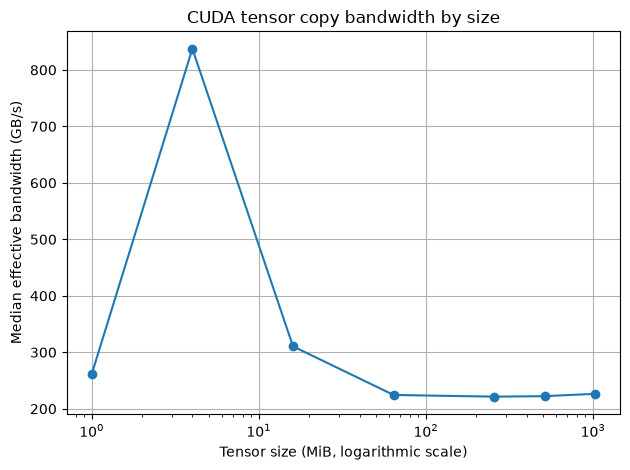

In [ ]:
assert len(copy_frame) == (len(COPY_SIZE_MIB) * COPY_MEASUREMENT_ITERATIONS)

assert copy_frame["elapsed_ms"].gt(0).all()
assert copy_frame["effective_bandwidth_gbs"].gt(0).all()

copy_plot = copy_summary.plot(
    x="size_mib",
    y="median_bandwidth_gbs",
    marker="o",
    logx=True,
    legend=False,
    xlabel="Tensor size (MiB, logarithmic scale)",
    ylabel="Median effective bandwidth (GB/s)",
    title="CUDA tensor copy bandwidth by size",
    grid=True,
)

copy_plot.figure.tight_layout()

### Prediction: small-working-set transition

The previous copy experiment showed an exceptional result for a 4 MiB tensor and a stable throughput regime from 64 MiB onward.

Because the same source and destination tensors were copied repeatedly, small buffers may have remained in GPU cache after warm-up. If so, increasing the combined source-plus-destination working set should reveal a transition from a cache-sensitive region to the sustained-memory region.

The transition need not identify the exact capacity of one hardware cache:

- source and destination data may occupy cache differently;
- cache replacement and write policies matter;
- other GPU state consumes cache capacity;
- the copy implementation may change with size;
- multiple cache levels may contribute.

The experiment therefore seeks an empirical working-set transition, not a definitive hardware cache-size measurement.

In [ ]:
SMALL_COPY_SIZE_MIB = [
    1,
    2,
    4,
    6,
    8,
    12,
    16,
    24,
    32,
    48,
    64,
    96,
    128,
]

SMALL_COPY_WARMUP_ITERATIONS = 20
SMALL_COPY_MEASUREMENT_ITERATIONS = 100


def measure_repeated_cuda_copy(
    size_mib: int,
) -> list[dict[str, int | float]]:
    size_bytes = size_mib * MIB
    element_size = torch.empty(
        (),
        dtype=COPY_DTYPE,
    ).element_size()
    count = size_bytes // element_size

    source = torch.ones(
        count,
        dtype=COPY_DTYPE,
        device=device,
    )
    destination = torch.empty_like(source)

    for _ in range(SMALL_COPY_WARMUP_ITERATIONS):
        destination.copy_(source)

    torch.cuda.synchronize(device)

    rows: list[dict[str, int | float]] = []

    for iteration in range(SMALL_COPY_MEASUREMENT_ITERATIONS):
        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)

        start_event.record()
        destination.copy_(source)
        end_event.record()
        end_event.synchronize()

        elapsed_ms = start_event.elapsed_time(end_event)
        logical_traffic_bytes = 2 * size_bytes

        rows.append(
            {
                "tensor_size_mib": size_mib,
                "combined_working_set_mib": 2 * size_mib,
                "iteration": iteration,
                "elapsed_us": elapsed_ms * 1_000,
                "effective_bandwidth_gbs": (
                    logical_traffic_bytes / (elapsed_ms / 1_000) / 1e9
                ),
            }
        )

    sample = destination[[0, count // 2, count - 1]].cpu()
    torch.testing.assert_close(sample, torch.ones_like(sample))

    del source
    del destination
    del sample

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize(device)

    return rows

In [ ]:
small_copy_rows: list[dict[str, int | float]] = []

for size_mib in SMALL_COPY_SIZE_MIB:
    print(
        f"Measuring {size_mib:>3} MiB tensor "
        f"({2 * size_mib:>3} MiB combined working set)"
    )
    small_copy_rows.extend(measure_repeated_cuda_copy(size_mib))

small_copy_frame = pd.DataFrame(small_copy_rows)

small_copy_summary = (
    small_copy_frame.groupby(
        [
            "tensor_size_mib",
            "combined_working_set_mib",
        ]
    )
    .agg(
        iterations=("elapsed_us", "count"),
        median_elapsed_us=("elapsed_us", "median"),
        mean_elapsed_us=("elapsed_us", "mean"),
        median_bandwidth_gbs=(
            "effective_bandwidth_gbs",
            "median",
        ),
        mean_bandwidth_gbs=(
            "effective_bandwidth_gbs",
            "mean",
        ),
        minimum_bandwidth_gbs=(
            "effective_bandwidth_gbs",
            "min",
        ),
        maximum_bandwidth_gbs=(
            "effective_bandwidth_gbs",
            "max",
        ),
    )
    .reset_index()
)

display(small_copy_summary.round(3))

Measuring   1 MiB tensor (  2 MiB combined working set)
Measuring   2 MiB tensor (  4 MiB combined working set)
Measuring   4 MiB tensor (  8 MiB combined working set)
Measuring   6 MiB tensor ( 12 MiB combined working set)
Measuring   8 MiB tensor ( 16 MiB combined working set)
Measuring  12 MiB tensor ( 24 MiB combined working set)
Measuring  16 MiB tensor ( 32 MiB combined working set)
Measuring  24 MiB tensor ( 48 MiB combined working set)
Measuring  32 MiB tensor ( 64 MiB combined working set)
Measuring  48 MiB tensor ( 96 MiB combined working set)
Measuring  64 MiB tensor (128 MiB combined working set)
Measuring  96 MiB tensor (192 MiB combined working set)
Measuring 128 MiB tensor (256 MiB combined working set)


,tensor_size_mib,combined_working_set_mib,iterations,median_elapsed_us,mean_elapsed_us,median_bandwidth_gbs,mean_bandwidth_gbs,minimum_bandwidth_gbs,maximum_bandwidth_gbs
0,1,2,100,7.744,7.977,270.810,265.745,145.313,283.706
1,2,4,100,8.128,8.326,516.031,507.683,278.877,534.988
2,4,8,100,10.016,10.014,837.521,838.825,661.980,939.584
3,6,12,100,14.144,14.174,889.629,890.859,667.599,1000.550
4,8,16,100,23.296,23.467,720.176,716.122,616.085,783.689
5,12,24,100,70.752,70.856,355.691,355.260,325.780,368.698
6,16,32,100,115.104,115.130,291.514,291.477,277.842,298.569
7,24,48,100,202.176,202.202,248.950,248.930,241.348,252.304
8,32,64,100,286.080,286.195,234.581,234.494,230.304,236.940
9,48,96,100,459.280,460.160,219.176,218.784,198.394,220.753


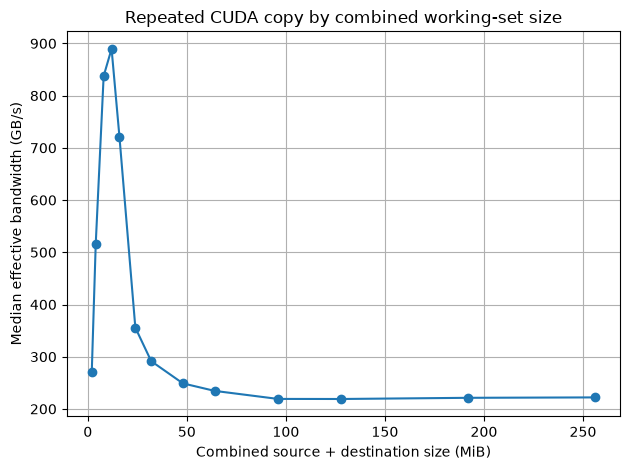

In [ ]:
assert len(small_copy_frame) == (
    len(SMALL_COPY_SIZE_MIB) * SMALL_COPY_MEASUREMENT_ITERATIONS
)

small_copy_plot = small_copy_summary.plot(
    x="combined_working_set_mib",
    y="median_bandwidth_gbs",
    marker="o",
    legend=False,
    xlabel="Combined source + destination size (MiB)",
    ylabel="Median effective bandwidth (GB/s)",
    title="Repeated CUDA copy by combined working-set size",
    grid=True,
)

small_copy_plot.figure.tight_layout()

## Observations

The CUDA runtime exposed one NVIDIA GB10 device with 121.689 GiB of CUDA-visible memory.

A `torch.float32` tensor with 134,217,728 elements required exactly 512 MiB of logical tensor storage.

The allocator snapshots were:

| Stage | Allocated MiB | Reserved MiB | Allocator slack MiB | CUDA-visible free MiB |
|---|---:|---:|---:|---:|
| Baseline after `empty_cache()` | 0 | 0 | 0 | 98,941.73 |
| 512 MiB tensor live | 512 | 512 | 0 | 98,417.00 |
| Tensor deleted; cache retained | 0 | 512 | 512 | 98,419.47 |
| After final `empty_cache()` | 0 | 0 | 0 | 98,931.35 |

While the tensor was live, both allocated and reserved memory increased by exactly 512 MiB.

After deleting the tensor and running garbage collection, allocated memory returned to zero while all 512 MiB remained reserved by the caching allocator.

After calling `torch.cuda.empty_cache()`, reserved memory also returned to zero.

CUDA-visible free memory did not change in exact correspondence with the PyTorch allocator values. It fell by approximately 524.73 MiB when the tensor was created and ended approximately 10.38 MiB below the initial snapshot after the cache was emptied.

### Cached allocation reuse

Thirty 512 MiB allocations were measured under two conditions.

| Condition | Minimum µs | Median µs | Mean µs | Maximum µs | Standard deviation µs |
|---|---:|---:|---:|---:|---:|
| Cache cleared before allocation | 19,160.15 | 19,428.73 | 19,466.93 | 20,231.79 | 205.65 |
| Same-size cached block available | 32.40 | 37.02 | 36.98 | 41.42 | 2.30 |

The median cached allocation was approximately 525 times faster than the median allocation performed after clearing the cache.

The timing ranges did not overlap. Every cached allocation was substantially faster than every uncached allocation in this run.

Both cases produced 512 MiB of allocated memory and 512 MiB of reserved memory while the tensor was live.

### Device tensor-copy bandwidth

CUDA event timing was used to measure 50 copies at each tensor size after ten warm-up copies.

Effective bandwidth counts one logical source read and one logical destination write, for a total of twice the tensor size.

| Tensor size MiB | Median elapsed ms | Median effective bandwidth GB/s |
|---:|---:|---:|
| 1 | 0.008 | 261.622 |
| 4 | 0.010 | 837.529 |
| 16 | 0.108 | 310.505 |
| 64 | 0.598 | 224.450 |
| 256 | 2.424 | 221.452 |
| 512 | 4.830 | 222.328 |
| 1,024 | 9.484 | 226.423 |

From 64 MiB through 1,024 MiB, median effective bandwidth remained between 221.452 and 226.423 GB/s.

Elapsed time scaled approximately in proportion to tensor size across that range. Doubling the tensor from 512 MiB to 1,024 MiB increased median elapsed time from 4.830 to 9.484 ms.

The small-copy results were not monotonic. The 4 MiB copy reported 837.529 GB/s, substantially above both smaller and larger sizes. It therefore does not belong to the stable large-transfer regime.

## Explanation

### Measured conclusions

PyTorch distinguishes live tensor storage from memory retained for later reuse.

`memory_allocated()` tracked the storage owned by the live tensor. Deleting the final tensor reference released that logical allocation.

`memory_reserved()` tracked the larger pool managed by PyTorch's CUDA caching allocator. Deleting the tensor made its 512 MiB block unused, but PyTorch retained the block rather than immediately returning it to CUDA.

`torch.cuda.empty_cache()` returned that unused cached block, reducing reserved memory to zero. It was not required to release the tensor itself; the tensor had already been released when its final reference was deleted.

For this single large allocation, the allocator introduced no visible rounding or fragmentation: allocated and reserved memory were both exactly 512 MiB while the tensor was live.

### Architectural interpretation

The imperfect correspondence between PyTorch allocator statistics and `torch.cuda.mem_get_info()` indicates that CUDA-visible free memory is broader than PyTorch tensor storage. CUDA runtime state, allocator metadata, context allocations, other processes, and measurement-time variation can affect it.

The approximately 10 MiB difference between the first and final free-memory snapshots should therefore not be interpreted as a leaked PyTorch tensor. Both PyTorch allocated and reserved memory returned to zero.

This experiment used `torch.empty`, which creates tensor storage without initializing the elements. It demonstrates CUDA allocation accounting, but it does not establish that every byte was physically read from or written to LPDDR5X.

On the DGX Spark, CPU and GPU memory are physically unified, but PyTorch and CUDA still expose device allocations and allocator ownership as distinct software concepts. Physical unification does not remove the need to distinguish live tensors, cached allocator blocks, CUDA runtime allocations, and actual memory traffic.

### Allocation latency and reuse

A PyTorch CUDA allocation does not have one fixed cost.

When a suitable block was already present in PyTorch's caching allocator, creating a new 512 MiB tensor took a median of 37.02 microseconds. When the cache was cleared first, the same request took a median of 19.43 milliseconds.

This approximately 525-fold difference demonstrates the practical purpose of the caching allocator: tensor destruction and subsequent allocation can be extremely cheap when storage is retained and reused.

The experiment measures host-side `torch.empty` latency. It does not measure initialization bandwidth because no kernel wrote the tensor contents. The uncached duration may include CUDA runtime, driver, virtual-memory, and allocator work and should not be interpreted as the time required to transfer 512 MiB through LPDDR5X.

Calling `torch.cuda.empty_cache()` can therefore reduce visible reserved memory, but it also discards blocks that make later allocations inexpensive. It is a memory-management operation rather than a general performance optimization.

### Device-copy throughput regimes

The measurements reveal a stable large-transfer regime beginning at approximately 64 MiB in this experiment. Between 64 MiB and 1,024 MiB, effective logical bandwidth remained close to 223 GB/s and elapsed time scaled almost linearly with tensor size.

This supports the interpretation that these larger copies are primarily limited by sustained movement of source and destination data rather than fixed launch overhead.

The metric counts two logical bytes of traffic for each byte of tensor storage: one source read and one destination write. It is therefore an effective copy-bandwidth metric, not a direct measurement of raw LPDDR5X bus bandwidth.

The 1, 4, and 16 MiB results do not form a simple launch-overhead curve. In particular, the 4 MiB result of approximately 838 GB/s cannot represent sustained external-memory traffic on the same basis as the larger copies.

A likely architectural explanation is cache reuse. The experiment repeatedly copies the same initialized source and destination buffers after warm-up. Smaller working sets may be served substantially from GPU cache rather than LPDDR5X. CUDA-event resolution and fixed timing costs may also have a greater relative effect when operations take only a few microseconds.

This cache interpretation remains an inference. The current experiment measures elapsed CUDA-stream time but does not identify which cache level or physical memory supplied each access.

## Connection to LLMs

Weights, activations, and KV caches place sustained pressure on memory capacity and bandwidth.

## Further Exploration

TODO: Compare access patterns, data types, and reuse while controlling synchronization.